<a href="https://colab.research.google.com/github/cbedart/EGBSL_VLS/blob/main/EGBSL_2026_Virtual_screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**<center><h1>EGBSL - Structure-based virtual screening</h1></center>**



---



# Software installation

In [ ]:
# @markdown ### => Click the play button below to install all the prerequisites software. Should take ~2 minutes

!wget https://github.com/gnina/gnina/releases/download/v1.0.3/gnina
!chmod +x gnina
!pip install py3Dmol
!apt install openbabel
!pip3 install rdkit

################################################################################~

from ipywidgets import interact,fixed,IntSlider
import ipywidgets
import py3Dmol
from IPython.display import display, HTML

from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, Descriptors, PandasTools, QED
from rdkit.Chem.FilterCatalog import FilterCatalogParams, FilterCatalog
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

################################################################################~

def blockPrint():
    sys.stdout = open(os.devnull, 'w')

def enablePrint():
    sys.stdout = sys.__stdout__

RDLogger.DisableLog('rdApp.*')

################################################################################~

def top3_poses(docked_sdf, rec="rec.pdb", lig="lig.pdb", display=display):
    ids = ["Pose #1", "Pose #2", "Pose #3"]
    supplier = Chem.SDMolSupplier(docked_sdf)
    molecules = [Chem.MolToMolBlock(mol) for mol in supplier if mol is not None]
    scores = [mol.GetProp("minimizedAffinity") for mol in supplier if mol is not None]

    lig_ref = Chem.MolFromPDBFile(lig)
    # rmsd = [AllChem.CalcRMS(lig_ref, mol, map=lig_ref.GetSubstructMatch(mol)) for mol in supplier if mol is not None]

    html_str = '''
    <table class="center">
    <tr>
    <td><h2 style="text-align:center;">{0}</h2></td>
    <td><h2 style="text-align:center;">{1}</h2></td>
    <td><h2 style="text-align:center;">{2}</h2></td>
    </tr>
    <tr>
    <td id="{0}">{3}</td>
    <td id="{1}">{4}</td>
    <td id="{2}">{5}</td>
    </tr>
    </table>
    '''

    html_str = html_str.format(ids[0], ids[1], ids[2], scores[0], scores[1], scores[2])
    display(HTML(html_str))

    for i in range(3):
        viewer = py3Dmol.view(width=400, height=400)
        viewer.addModel(open('rec.pdb').read())
        viewer.setStyle({'cartoon':{},'stick':{'radius':0.15}})
        viewer.addModel(open('lig.pdb').read())
        viewer.setStyle({'model':1},{'stick':{'colorscheme':'greenCarbon'}})
        viewer.addModel(molecules[i])
        viewer.setStyle({'model':2},{'stick':{'colorscheme':'cyanCarbon'}})
        viewer.zoomTo({'model':1})
        viewer.insert(ids[i])
    return

################################################################################~

def CB_Gnina_pandas(input_sdf, active):
    temp = PandasTools.LoadSDF(input_sdf)
    temp["minimizedAffinity"] = pd.to_numeric(temp["minimizedAffinity"])
    temp = temp.sort_values("minimizedAffinity").drop_duplicates("ID")
    temp.index = range(len(temp))

    temp["Active"] = active
    temp[["MW", "LogP", "HBA", "HBD", "PSA", "RotB", "Arom", "Alerts", "PAINS"]] = 0

    smiles_list = []
    for rowid_temp in range(len(temp)):
        smiles_list.append(Chem.MolToSmiles(temp.loc[rowid_temp,"ROMol"]))
        temp.loc[rowid_temp, ["MW", "LogP", "HBA", "HBD", "PSA", "RotB", "Arom", "Alerts"]] = [round(i,2) for i in QED.properties(temp["ROMol"][rowid_temp])]

    temp["ROMol"] = smiles_list
    return temp


################################################################################~

def CB_AUC(data_x, data_y):
    calculated_auc = 0
    for i in range(len(data_x)-1):
        auc_temp = (data_y[i] + data_y[i+1]) * (data_x[i+1] - data_x[i]) / 2
        calculated_auc = calculated_auc + auc_temp
    return calculated_auc

################################################################################~

!wget https://github.com/cbedart/EGBSL_VLS/raw/refs/heads/main/retrospective_data.pkl
results_gr_sorted = pd.read_pickle("/content/retrospective_data.pkl")
results_gr_sorted_VA = results_gr_sorted.sort_values("minimizedAffinity", ascending=True).drop_duplicates(subset='ID', keep='first')
results_gr_sorted_CS = results_gr_sorted.sort_values("CNNscore", ascending=False).drop_duplicates(subset='ID', keep='first')
results_gr_sorted_CA = results_gr_sorted.sort_values("CNNaffinity", ascending=False).drop_duplicates(subset='ID', keep='first')
results_gr_sorted_VS = results_gr_sorted.sort_values("CNN_VS", ascending=False).drop_duplicates(subset='ID', keep='first')

################################################################################~

!wget https://github.com/cbedart/EGBSL_VLS/raw/refs/heads/main/VLS_GR_5UC1_docked_rescored.zip
!unzip -n VLS_GR_5UC1_docked_rescored.zip > /dev/null 2>&1
results_vls = pd.read_pickle("VLS_GR_5UC1_docked_rescored.pkl")
results_vls.drop(columns=["E_tot", "fmax", "Converged", "E_rel(kcal/mol)", "fma", "mi"], inplace=True)

################################################################################~



# Part 1. Molecular docking...?

## Choose your PDB file

Choose your PDB crystallographic file from the [RCSB Protein Data Bank](https://www.rcsb.org/) or the [Protein Data Bank in Europe PDBe](https://www.ebi.ac.uk/pdbe/).

You need:
1. The PDB ID code of your crystallographic 3D structure of your protein of interest,
2. The main chain of the protein,
3. The Ligand ID code of the associated ligand.


Here, for the reference human structure from the protein modeling session - [glucocorticoid receptor beta](https://www.rcsb.org/structure/5UC1):
1. The PDB ID code is **5UC1**
2. Here, the main chain we want to study can be either A or B, but we will select the chain **A**.
3. The Ligand ID for the RU-486 is **486**

In [ ]:
#@markdown This block will download for you the crystallographic structure, and split the receptor and the ligand from the other elements. Press play once you have completed the information on the form below

pdb_id = "" # @param {type:"string"}
ligand_id = "" # @param {type:"string"}
chain_id = "" # @param {type:"string"}

!wget http://files.rcsb.org/download/{pdb_id}.pdb -O /content/downloaded.pdb
!grep -E "ATOM.*[A-Z][A-Z][A-Z] {chain_id}" downloaded.pdb > rec.pdb
!grep "{ligand_id} {chain_id}" downloaded.pdb > lig.pdb

print("Receptor {} with ligand {} downloaded successfully".format(pdb_id, ligand_id))

## Run the docking

In [ ]:
!./gnina -r rec.pdb -l lig.pdb --autobox_ligand lig.pdb --seed 0 -o docked.sdf --cnn_scoring=none --no_gpu

In [ ]:
top3_poses("docked.sdf")

# Part 2. “Perspective will come in retrospect.” (Retrospective docking)

Retrospective docking using the DUD-E subset for Glucocorticoid receptor : [https://dude.docking.org/targets/gcr](https://dude.docking.org/targets/gcr) (Crystallographic structure = 3BQD)

Here, using Gnina, screening of:
*   258 active ligands
*   14903 decoys



In [ ]:
# @markdown ### => Scoring function - Vina Affinity
results_gr_sorted_VA

In [ ]:
# @markdown ### => Scoring function - CNN Pose Sore

results_gr_sorted_CS

In [ ]:
# @markdown ### => Scoring function - CNN Affinity

results_gr_sorted_CA

In [ ]:
# @markdown ### => Scoring function - CNN VS (made using the formula CNN Affinity * CNN Pose Score)
results_gr_sorted_VS

In [ ]:
# @markdown ### => Plot the physicochemical descriptors

fig, axs = plt.subplots(3, 3, figsize=(12, 10))
axs[0,0].hist(results_gr_sorted["MW"], bins=30, color='dodgerblue')
axs[0,0].set_title('Molecular weight')
axs[0,1].hist(results_gr_sorted["ALOGP"], bins=30, color='dodgerblue')
axs[0,1].set_title('LogP')
axs[0,2].hist(results_gr_sorted["ROTB"], color='forestgreen')
axs[0,2].set_title('Rotatable bonds')

axs[1,0].hist(results_gr_sorted["HBA"], color='dodgerblue')
axs[1,0].set_title('Hydrogen bond acceptors')
axs[1,1].hist(results_gr_sorted["HBD"], color='dodgerblue')
axs[1,1].set_title('Hydrogen bond donors')
axs[1,2].hist(results_gr_sorted["PSA"], bins=30, color='forestgreen')
axs[1,2].set_title('Polar Surface Area')

arom_counts = results_gr_sorted["AROM"].value_counts()
axs[2,0].pie(arom_counts, labels=arom_counts.index, autopct='%1.1f%%', startangle=90)
axs[2,0].set_title('Number of Aromatic Rings')

alerts_counts = results_gr_sorted["ALERTS"].value_counts()
axs[2,1].pie(alerts_counts, labels=alerts_counts.index, autopct='%1.1f%%', startangle=90)
axs[2,1].set_title('Number of Structural Alerts')

steroid_counts = results_gr_sorted["STEROID"].value_counts()
axs[2,2].pie(steroid_counts, labels=steroid_counts.index, autopct='%1.1f%%', startangle=90)
axs[2,2].set_title('Steroid ring')

plt.tight_layout()
plt.show()

## Score distribution

In [ ]:
# @markdown ### => Plot the score distribution


fig, axs = plt.subplots(2, 2, figsize=(15, 10))

min_affinity_sorted = results_gr_sorted["minimizedAffinity"].sort_values(ascending=True).reset_index(drop=True)
axs[0, 0].plot(min_affinity_sorted, zorder=100)
axs[0, 0].set_title("Distribution of Vina affinity score (Sorted)")
axs[0, 0].set_xlabel("Compounds ranking")
axs[0, 0].set_ylabel("Vina affinity score")
axs[0, 0].axhline(0, color="grey", linestyle="dashed", linewidth=0.5)
axs[0, 0].axhline(-5, color="grey", linestyle="dashed", linewidth=0.5)
axs[0, 0].axhline(-10, color="grey", linestyle="dashed", linewidth=0.5)

cnn_score_sorted = results_gr_sorted["CNNscore"].sort_values(ascending=False).reset_index(drop=True)
axs[0, 1].plot(cnn_score_sorted, zorder=100, color='red')
axs[0, 1].set_title("Distribution of CNN Score (Sorted)")
axs[0, 1].set_xlabel("Compounds ranking")
axs[0, 1].set_ylabel("CNN Score")

cnn_affinity_sorted = results_gr_sorted["CNNaffinity"].sort_values(ascending=False).reset_index(drop=True)
axs[1, 0].plot(cnn_affinity_sorted, zorder=100, color='green')
axs[1, 0].set_title("Distribution of CNN Affinity (Sorted)")
axs[1, 0].set_xlabel("Compounds ranking")
axs[1, 0].set_ylabel("CNN Affinity")

cnn_vs_sorted = results_gr_sorted["CNN_VS"].sort_values(ascending=False).reset_index(drop=True)
axs[1, 1].plot(cnn_vs_sorted, zorder=100, color='purple')
axs[1, 1].set_title("Distribution of CNN VS (Sorted)")
axs[1, 1].set_xlabel("Compounds ranking")
axs[1, 1].set_ylabel("CNN VS")

plt.tight_layout()
plt.show()

## Enrichment curve and enrichment factors

Enrichment Factor (EF):

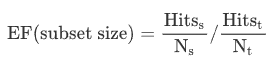

Where:
* Hits<sub>s</sub> = Number of active compounds in the sampled subset
* N<sub>s</sub> = Number of compounds in the sampled subset
* Hits<sub>t</sub> = Total number of active compounds
* N<sub>t</sub> = Total number of compounds

With a maximum Enrichment Factor of N<sub>t</sub> / Hits<sub>t</sub>

In [ ]:
# @title <b>Retrospective docking</b>

# @markdown Total of <b>15,158</b> compounds with <b>258</b> active compounds and <b>14,900</b> decoys.
top_percent = 5 # @param {type:"slider", min:0.1, max:10, step:0.1}
xlog_scale = False # @param {type:"boolean"}

nb_actives = 258
enrich_VA = [0] + list(results_gr_sorted_VA.sort_values("minimizedAffinity", ascending=True)["Active"].cumsum() / nb_actives)
enrich_CS = [0] + list(results_gr_sorted_CS.sort_values("CNNscore", ascending=False)["Active"].cumsum() / nb_actives)
enrich_CA = [0] + list(results_gr_sorted_CA.sort_values("CNNaffinity", ascending=False)["Active"].cumsum() / nb_actives)
enrich_VS = [0] + list(results_gr_sorted_VS.sort_values("CNN_VS", ascending=False)["Active"].cumsum() / nb_actives)

enrich_random = [i/nb_actives for i in np.linspace(0,nb_actives,len(results_gr_sorted_VA)+1)]
enrich_perfect = [i/nb_actives for i in list(range(0,nb_actives+1)) + list(np.repeat(nb_actives,len(results_gr_sorted_VA)-nb_actives))]

enrich_xaxis = np.linspace(0, 1, len(enrich_VA))

plt.figure(figsize=[12,7])
plt.title("Enrichment curve - Retrospective docking")

# retrospective_colors = ["#FFD166", "#EF476F", "#F78C6B", "#06D6A0", "#118AB2", "#073B4C"]
retrospective_colors = ["gold", "red", "#F78C6B", "#06D6A0", "#118AB2", "#073B4C"]

plt.plot(enrich_xaxis, enrich_perfect, color = retrospective_colors[0], linewidth=2)
plt.plot(enrich_xaxis, enrich_random, color = retrospective_colors[1], linewidth=2)

plt.plot(enrich_xaxis, enrich_VA, color = retrospective_colors[2], linewidth=2)
plt.plot(enrich_xaxis, enrich_CS, color = retrospective_colors[3], linewidth=2)
plt.plot(enrich_xaxis, enrich_CA, color = retrospective_colors[4], linewidth=2)
plt.plot(enrich_xaxis, enrich_VS, color = retrospective_colors[5], linewidth=2)

leg = plt.legend(["Perfect", "Random", "Vina Affinity", "CNN Score", "CNN Affinity", "CNN VS"])
for line in leg.get_lines():
    line.set_linewidth(5)

plt.xlabel("%database (False Positive Fraction - FPF)")
plt.ylabel("%actives (True Positive Fraction - TPF)")

if xlog_scale:
  plt.xscale("log")

top_percent = top_percent / 100
top_id = round(len(results_gr_sorted_VA)*top_percent)

plt.plot([enrich_xaxis[top_id], enrich_xaxis[top_id], enrich_xaxis[top_id], enrich_xaxis[top_id], enrich_xaxis[top_id], enrich_xaxis[top_id]], [enrich_VA[top_id], enrich_CA[top_id], enrich_CS[top_id], enrich_VS[top_id],enrich_random[top_id], enrich_perfect[top_id]], "ro", zorder=100, linestyle="dotted")

enrichment_factors = [round(enrich_VA[top_id] / enrich_random[top_id], 2),
                      round(enrich_CS[top_id] / enrich_random[top_id], 2),
                      round(enrich_CA[top_id] / enrich_random[top_id], 2),
                      round(enrich_VS[top_id] / enrich_random[top_id], 2)]

enrichment_scores = ["Below {}".format(round(results_gr_sorted_VA["minimizedAffinity"].sort_values(ascending=True).iloc[top_id],2)),
                     "Above {}".format(round(results_gr_sorted_CS["CNNscore"].sort_values(ascending=False).iloc[top_id],2)),
                     "Above {}".format(round(results_gr_sorted_CA["CNNaffinity"].sort_values(ascending=False).iloc[top_id],2)),
                     "Above {}".format(round(results_gr_sorted_VS["CNN_VS"].sort_values(ascending=False).iloc[top_id],2))]

retrospective_results = pd.DataFrame({"Scoring Function":["Vina Affinity", "CNN Score", "CNN Affinity", "CNN VS"],
                                      "Enrichment factor at {0}%".format(round(top_percent*100,2)):enrichment_factors,
                                      "Correspond to a score of":enrichment_scores})

display(retrospective_results)

print("Maximum enrichment factor at {}% than can be obtained = {}\n".format(round(top_percent*100,2), round(enrich_perfect[top_id] / enrich_random[top_id], 2)))

plt.show()




# Part 3. So… Prospective will come after retrospect?  (Prospective docking)

**Step #1** = Setup your protein structure. We use here the 5UC1 structure, since we validated it.

Sometimes you also have to add hydrogens, but Vina-derived software does not take them into account.  

<br />

**Step #2** = Select your ligands. Either a chemical library, in-house compounds, or a user-created focused chemical library. Here, the ~43,000 closest compounds in terms of similarity to CHEMBL4061359 (IC50 = 0.029 nM & not a steroid ligand), using Zinc20 and the compounds in stock in 2019 Q4 (i.e. compounds that exist or have existed commercially).

<br />
  
**Step #3** = Generate the 3D coordinates of the ligands. You have to generate the tautomers, protomers, charges, etc. but we will avoid this today. Sometimes you also have to add hydrogens, but Vina-derived software does not take them into account.

<br />

**Step #4** = Virtual screening using Gnina. The box is setup automatically around the crystallized ligand, but ideally you have to setup your own box. It's very important to keep the same parameters validated in the retrospective screening. Here, only the best pose was kept based on the Vina affinity scoring function (minimizedAffinity), but you can (and you have to normally) do  the same with each scoring function.

In [ ]:
# @markdown ### => Load the dataset
results_vls


In [ ]:
# @markdown ### => Plot the physicochemical descriptors

fig, axs = plt.subplots(3, 3, figsize=(12, 10))
axs[0,0].hist(results_vls["MW"], bins=30, color='dodgerblue')
axs[0,0].set_title('Molecular weight')
axs[0,1].hist(results_vls["ALOGP"], bins=30, color='dodgerblue')
axs[0,1].set_title('LogP')
axs[0,2].hist(results_vls["ROTB"], color='forestgreen')
axs[0,2].set_title('Rotatable bonds')

axs[1,0].hist(results_vls["HBA"], color='dodgerblue')
axs[1,0].set_title('Hydrogen bond acceptors')
axs[1,1].hist(results_vls["HBD"], color='dodgerblue')
axs[1,1].set_title('Hydrogen bond donors')
axs[1,2].hist(results_vls["PSA"], bins=30, color='forestgreen')
axs[1,2].set_title('Polar Surface Area')

arom_counts = results_vls["AROM"].value_counts()
axs[2,0].pie(arom_counts, labels=arom_counts.index, autopct='%1.1f%%', startangle=90)
axs[2,0].set_title('Number of Aromatic Rings')

alerts_counts = results_vls["ALERTS"].value_counts()
axs[2,1].pie(alerts_counts, labels=alerts_counts.index, autopct='%1.1f%%', startangle=90)
axs[2,1].set_title('Number of Structural Alerts')

steroid_counts = results_vls["STEROID"].value_counts()
axs[2,2].pie(steroid_counts, labels=steroid_counts.index, autopct='%1.1f%%', startangle=90)
axs[2,2].set_title('Steroid ring')

plt.tight_layout()
plt.show()

In [ ]:
# @markdown ### => Filter the results, and download the top X compounds :

# @markdown ## <font color="#FF5555">**Top X% to keep:**</font>
top_percent = 0.5 # @param {type:"slider", min:0.1, max:10, step:0.1}

# @markdown ## <font color="purple">**Scoring function:**</font>
scoring_function = "Vina Affinity" # @param ["Vina Affinity", "CNN Pose Score", "CNN Affinity", "CNN VS"] {type:"string"}

# @markdown ## <font color="dodgerblue">**Molecular weight:**</font>
mw_minimum = 350 # @param {type:"integer"}
mw_maximum = 450 # @param {type:"integer"}

# @markdown ## <font color="dodgerblue">**Hydrogen bonds acceptors:**</font>
hba_minimum = 0 # @param {type:"integer"}
hba_maximum = 20 # @param {type:"integer"}

# @markdown ## <font color="dodgerblue">**Hydrogen bonds donors:**</font>
hbd_minimum = 0 # @param {type:"integer"}
hbd_maximum = 4 # @param {type:"integer"}

# @markdown ## <font color="dodgerblue">**LogP:**</font>
logP_minimum = -10 # @param {type:"integer"}
logP_maximum = 5 # @param {type:"integer"}

# @markdown ## <font color="forestgreen">**Rotatable bonds:**</font>
rotb_minimum = 0 # @param {type:"integer"}
rotb_maximum = 10 # @param {type:"integer"}

# @markdown ## <font color="forestgreen">**Polar surface area:**</font>
psa_minimum = 0 # @param {type:"integer"}
psa_maximum = 120 # @param {type:"integer"}

# @markdown ## <font color="darkorange">**Number of aromatic rings:**</font>
aro_minimum = 0 # @param {type:"integer"}
aro_maximum = 20 # @param {type:"integer"}

# @markdown ## <font color="darkorange">**Number of structural alerts:**</font>
alerts_maximum = 1 # @param ["0","1","2","3","4+"] {type:"raw"}

################################################################################

filtered_vls = results_vls.copy()

if scoring_function == "Vina Affinity":
    filtered_vls.sort_values("minimizedAffinity", ascending=True, inplace=True)
elif scoring_function == "CNN Pose Score":
    filtered_vls.sort_values("CNNscore", ascending=False, inplace=True)
elif scoring_function == "CNN Affinity":
    filtered_vls.sort_values("CNNaffinity", ascending=False, inplace=True)
elif scoring_function == "CNN VS":
    filtered_vls.sort_values("CNN_VS", ascending=False, inplace=True)
else:
    raise ValueError("Invalid scoring function")

filtered_vls.reset_index(drop=True, inplace=True)
filtered_vls

filtered_vls = filtered_vls.iloc[range(0, round(len(filtered_vls) * (top_percent / 100)))]

filtered_vls = filtered_vls[(filtered_vls["MW"] >= mw_minimum) & (filtered_vls["MW"] <= mw_maximum)]
filtered_vls = filtered_vls[(filtered_vls["HBA"] >= hba_minimum) & (filtered_vls["HBA"] <= hba_maximum)]
filtered_vls = filtered_vls[(filtered_vls["HBD"] >= hbd_minimum) & (filtered_vls["HBD"] <= hbd_maximum)]
filtered_vls = filtered_vls[(filtered_vls["ALOGP"] >= logP_minimum) & (filtered_vls["ALOGP"] <= logP_maximum)]
filtered_vls = filtered_vls[(filtered_vls["ROTB"] >= rotb_minimum) & (filtered_vls["ROTB"] <= rotb_maximum)]
filtered_vls = filtered_vls[(filtered_vls["PSA"] >= psa_minimum) & (filtered_vls["PSA"] <= psa_maximum)]
filtered_vls = filtered_vls[(filtered_vls["AROM"] >= aro_minimum) & (filtered_vls["AROM"] <= aro_maximum)]
filtered_vls = filtered_vls[filtered_vls["ALERTS"] <= int(alerts_maximum)]

filtered_vls

################################################################################

In [ ]:
# @markdown ### => Download the top X compounds of your selection:
top_nb = 2 # @param {type:"slider", min:1, max:10, step:1}

!rm EGBSL_5UC1_chosen.sdf

top_nb = int(top_nb)

if top_nb > len(filtered_vls):
  top_nb = len(filtered_vls)

top_chosen = filtered_vls.iloc[0:top_nb]

with Chem.SDWriter('EGBSL_5UC1_chosen.sdf') as filout:
  for i in range(len(top_chosen)):
    top_chosen_i = top_chosen.iloc[i]
    cpd_temp = top_chosen_i["ROMol"]
    cpd_temp.SetProp('_Name', top_chosen_i["ID"])
    filout.write(cpd_temp)

files.download('EGBSL_5UC1_chosen.sdf')
files.download('receptor.pdb')

In [ ]:
# @markdown ### => Test it with a specific SMILES string if you want:

smiles_input = "" # @param {type:"string"}
number_poses = 10  # @param {type:"slider", min:2, max:50, step:2}
use_gpu = False # @param {type:"boolean"}
if smiles_input:
    with open("input_lig.smi", "w") as f:
        f.write(smiles_input)

    # Convert to 3D, protonate at pH 7.4, and output:
    !obabel input_lig.smi -O lig.sdf --gen3D -p 7.4

    if use_gpu:
        !./gnina -r receptor.pdb -l lig.sdf --autobox_ligand crystal_ligand.mol2 --seed 0 -o docked.sdf
    else:
        !./gnina -r receptor.pdb -l lig.sdf --autobox_ligand crystal_ligand.mol2 --seed 0 -o docked.sdf --cnn_scoring=none --no_gpu

    # Download the docked.sdf file
    files.download('docked.sdf')

    print("Docking complete and docked.sdf downloaded!")
else:
    print("Please enter a SMILES string to dock.")

**<h1>CUSTOM - Only use it when you don't want to run the previous cells anymore</h1>**



---



In [ ]:
# @markdown ### => Prepare your protein for the docking...

pdb_id = "" # @param {type:"string"}
chain_id = "" # @param {type:"string"}
ligand_id = "" # @param {type:"string"}

!wget http://files.rcsb.org/download/{pdb_id}.pdb -O /content/downloaded.pdb
!grep -E "ATOM.*[A-Z][A-Z][A-Z] {chain_id}" downloaded.pdb > rec.pdb
!grep "{ligand_id} {chain_id}" downloaded.pdb > lig.pdb


!rm downloaded.pdb
files.download('rec.pdb')
files.download('lig.pdb')

In [ ]:
# @markdown ### => ... and dock a specific SMILES string :

smiles_input = "" # @param {type:"string"}
number_poses = 16  # @param {type:"slider", min:2, max:50, step:2}
use_gpu = False # @param {type:"boolean"}
if smiles_input:
    with open("input_lig.smi", "w") as f:
        f.write(smiles_input)

    # Convert to 3D, protonate at pH 7.4, and output:
    !obabel input_lig.smi -O lig.sdf --gen3D -p 7.4

    if use_gpu:
        !./gnina -r rec.pdb -l lig.sdf --autobox_ligand lig.pdb --num_modes {number_poses} --seed 0 -o docked.sdf
    else:
        !./gnina -r rec.pdb -l lig.sdf --autobox_ligand lig.pdb --num_modes {number_poses} --seed 0 -o docked.sdf --cnn_scoring=none --no_gpu

    # Download the docked.sdf file
    files.download('docked.sdf')

    print("Docking complete and docked.sdf downloaded!")
else:
    print("Please enter a SMILES string to dock.")